<a href="https://colab.research.google.com/github/ahammedzihadkhan/-/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import io


uploaded = files.upload()


filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Successfully uploaded and loaded: {filename}")
display(df.head())

Saving data.csv to data.csv
Successfully uploaded and loaded: data.csv


,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


### Identifying Guest / Non-Logged-in Customers
We can analyze customers with very low 'Length of Membership' as potential guests or one-time purchasers.

In [ ]:

guest_customers = df[df['Length of Membership'] < 1]

print(f"Found {len(guest_customers)} potential guest/new customers.")
display(guest_customers.sort_values(by='Length of Membership'))

Found 5 potential guest/new customers.


,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
447,sharongraves@yahoo.com,"73098 Ronald PortCliffordborough, MO 37479-9244",Wheat,12.56,37.81,0.27,314.44
225,alexandra26@summers-davis.com,Unit 7032 Box 7016DPO AE 44749-2992,Navy,10.26,36.14,0.79,256.67
173,fischermonica@gmail.com,9847 Michael Plaza Suite 837Lake Christophersh...,Navy,11.75,36.94,0.80,298.76
434,jordandavid@gmail.com,"61502 Parker Vista Apt. 363Jonesshire, GU 33532",Violet,10.99,36.35,0.94,304.14
161,stevenking@patterson.com,"94730 Martin MountNew Matthew, VI 08142-6708",LightGray,12.40,35.01,0.97,357.59


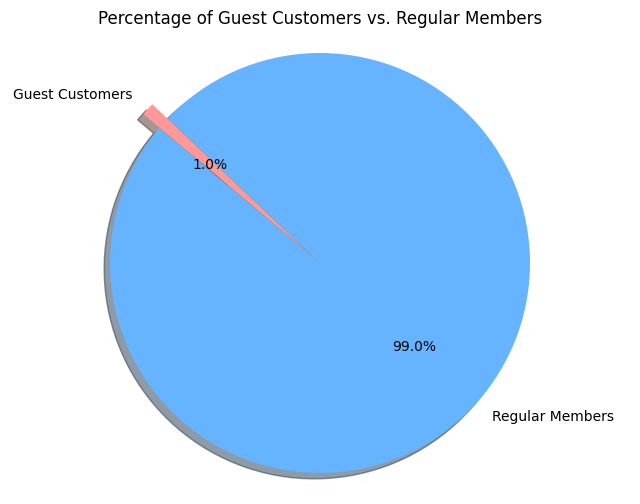

In [ ]:
import matplotlib.pyplot as plt


total_customers = len(df)
num_guests = len(guest_customers)
num_regular = total_customers - num_guests


labels = ['Regular Members', 'Guest Customers']
sizes = [num_regular, num_guests]
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)


plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=140, colors=colors)
plt.title('Percentage of Guest Customers vs. Regular Members')
plt.axis('equal') .
plt.show()

In [ ]:
from google.colab import files
import pandas as pd
import io

# Check if file was already uploaded to avoid re-uploading
try:
    df_2 = pd.read_csv('marketing_campaign.csv', sep='\t')
    print("Successfully re-loaded 'marketing_campaign.csv' with tab separator.")
    display(df_2.head())
except FileNotFoundError:
    print("Please upload your second dataset:")
    uploaded_2 = files.upload()
    if uploaded_2:
        filename_2 = list(uploaded_2.keys())[0]
        df_2 = pd.read_csv(io.BytesIO(uploaded_2[filename_2]), sep='\t')
        print(f"Successfully uploaded and loaded: {filename_2}")
        display(df_2.head())
    else:
        print("No file was uploaded.")

Successfully re-loaded 'marketing_campaign.csv' with tab separator.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
import pandas as pd
from datetime import datetime

# Convert Dt_Customer to datetime objects
df_2['Dt_Customer'] = pd.to_datetime(df_2['Dt_Customer'], dayfirst=True)

# Calculate length of membership in years (using the max date in the dataset as a reference point)
reference_date = df_2['Dt_Customer'].max()
df_2['Membership_Years'] = (reference_date - df_2['Dt_Customer']).dt.days / 365.25

# Define 'guests' as customers with less than 1 year of membership
guest_customers_2 = df_2[df_2['Membership_Years'] < 1]

print(f"Found {len(guest_customers_2)} guest/new customers in the second dataset.")
display(guest_customers_2[['ID', 'Dt_Customer', 'Membership_Years']].head())

Found 1159 guest/new customers in the second dataset.


,ID,Dt_Customer,Membership_Years
1,2174,2014-03-08,0.309377
2,4141,2013-08-21,0.854209
3,6182,2014-02-10,0.380561
4,5324,2014-01-19,0.440794
5,7446,2013-09-09,0.802190


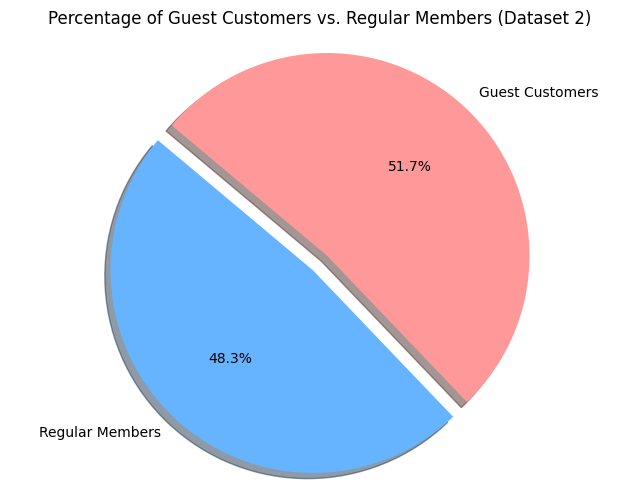

In [ ]:
import matplotlib.pyplot as plt

# Calculate counts for the second dataset
total_2 = len(df_2)
num_guests_2 = len(guest_customers_2)
num_regular_2 = total_2 - num_guests_2

# Data for plotting
labels = ['Regular Members', 'Guest Customers']
sizes = [num_regular_2, num_guests_2]
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140, colors=colors)
plt.title('Percentage of Guest Customers vs. Regular Members (Dataset 2)')
plt.axis('equal')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Selecting numerical features for clustering similar guests in Dataset 2
# We'll use Income and spending on different categories
features = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Membership_Years']

# Drop rows with missing values in these features
clust_df = df_2.dropna(subset=features).copy()

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clust_df[features])

# Apply K-Means (let's find 4 clusters of similar customers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clust_df['Cluster'] = kmeans.fit_predict(scaled_features)

print("K-Means Clustering complete. Here is a sample of similar guests grouped by Cluster:")
display(clust_df[['ID', 'Income', 'Membership_Years', 'Cluster']].head(10))

K-Means Clustering complete. Here is a sample of similar guests grouped by Cluster:


,ID,Income,Membership_Years,Cluster
0,5524,58138.0,1.815195,2
1,2174,46344.0,0.309377,0
2,4141,71613.0,0.854209,1
3,6182,26646.0,0.380561,0
4,5324,58293.0,0.440794,0
5,7446,62513.0,0.802190,1
6,965,55635.0,1.623546,3
7,6177,33454.0,1.141684,3
8,4855,30351.0,1.062286,3
9,5899,5648.0,0.295688,0


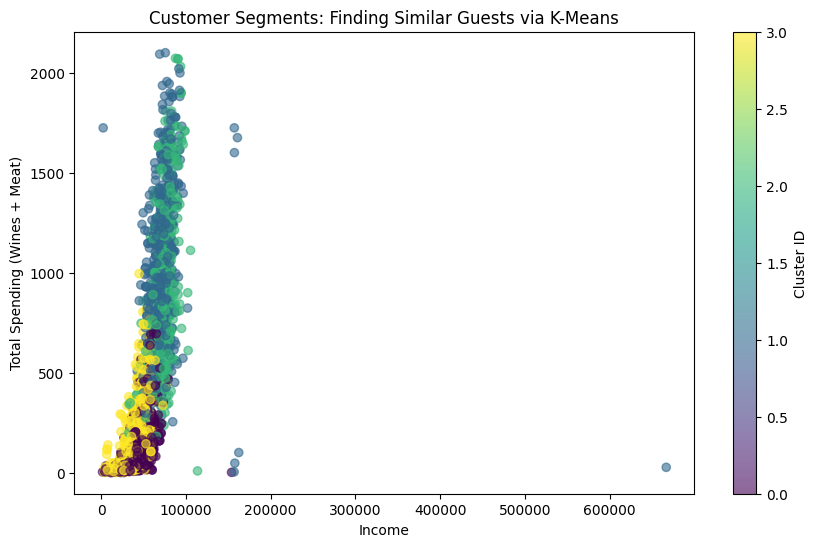

In [ ]:
# Visualize the clusters based on Income and total spending
plt.figure(figsize=(10, 6))
scatter = plt.scatter(clust_df['Income'],
                      clust_df['MntWines'] + clust_df['MntMeatProducts'],
                      c=clust_df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Income')
plt.ylabel('Total Spending (Wines + Meat)')
plt.title('Customer Segments: Finding Similar Guests via K-Means')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [ ]:
from google.colab import files
import pandas as pd
import io

print("Please upload your third dataset:")
uploaded_3 = files.upload()

if uploaded_3:
    filename_3 = list(uploaded_3.keys())[0]
    # Defaulting to comma separator, change to sep='\t' if needed
    try:
        df_3 = pd.read_csv(io.BytesIO(uploaded_3[filename_3]))
        print(f"Successfully uploaded and loaded: {filename_3}")
        display(df_3.head())
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print("No file was uploaded.")

Please upload your third dataset:


Saving E-commerce Customer Behavior - Sheet1.csv to E-commerce Customer Behavior - Sheet1.csv
Successfully uploaded and loaded: E-commerce Customer Behavior - Sheet1.csv


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


### Guest Analysis for Dataset 3 (E-commerce Customer Behavior)
Since this dataset lacks a membership date, we will define 'guests' as customers with a **Total Spend < $500**.

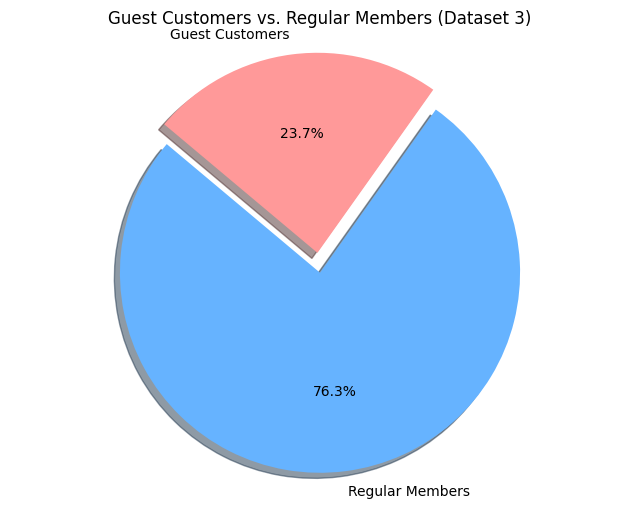

In [ ]:
import matplotlib.pyplot as plt

# Define guests in Dataset 3 (df_3) based on Total Spend
guest_customers_3 = df_3[df_3['Total Spend'] < 500]

# Calculate counts
total_3 = len(df_3)
num_guests_3 = len(guest_customers_3)
num_regular_3 = total_3 - num_guests_3

# Pie Chart
plt.figure(figsize=(8, 6))
plt.pie([num_regular_3, num_guests_3], labels=['Regular Members', 'Guest Customers'],
        autopct='%1.1f%%', shadow=True, startangle=140, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1))
plt.title('Guest Customers vs. Regular Members (Dataset 3)')
plt.axis('equal')
plt.show()

In [ ]:
 from google.colab import files
import pandas as pd
import io

# Re-loading with the correct encoding for the Online Retail dataset
try:
    # Using 'ISO-8859-1' which is common for this specific dataset
    df_next = pd.read_csv('/content/data (1).csv', encoding='ISO-8859-1')
    print("Successfully loaded 'data (1).csv' with ISO-8859-1 encoding.")
    display(df_next.head())
except Exception as e:
    print(f"Still having trouble loading: {e}")

Successfully loaded 'data (1).csv' with ISO-8859-1 encoding.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Guest Analysis for Online Retail Dataset
For this dataset, we will define 'guests' as customers who have only made a **single purchase** (Frequency = 1).

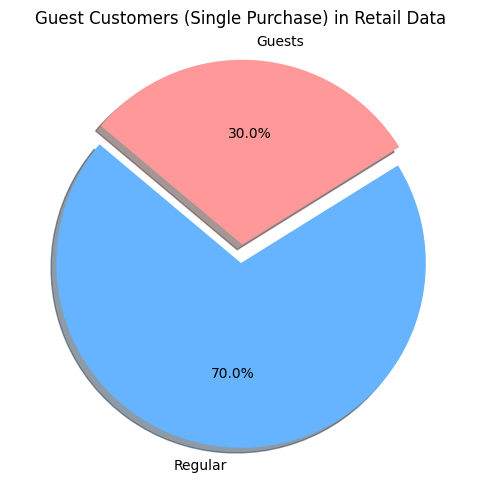

In [ ]:
import matplotlib.pyplot as plt

# 1. Guest Analysis (Single Purchase)
# Ensure we drop rows where CustomerID is missing as is common in retail data
retail_data = df_next.dropna(subset=['CustomerID'])
freq_df = retail_data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
freq_df.columns = ['CustomerID', 'Frequency']

num_guests_next = len(freq_df[freq_df['Frequency'] == 1])
num_regular_next = len(freq_df) - num_guests_next

plt.figure(figsize=(8, 6))
plt.pie([num_regular_next, num_guests_next], labels=['Regular', 'Guests'],
        autopct='%1.1f%%', shadow=True, startangle=140, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1))
plt.title('Guest Customers (Single Purchase) in Retail Data')
plt.show()

### Behavioral Clustering (K-Means)
We will group customers based on their **Frequency** and **Total Monetary Value**.

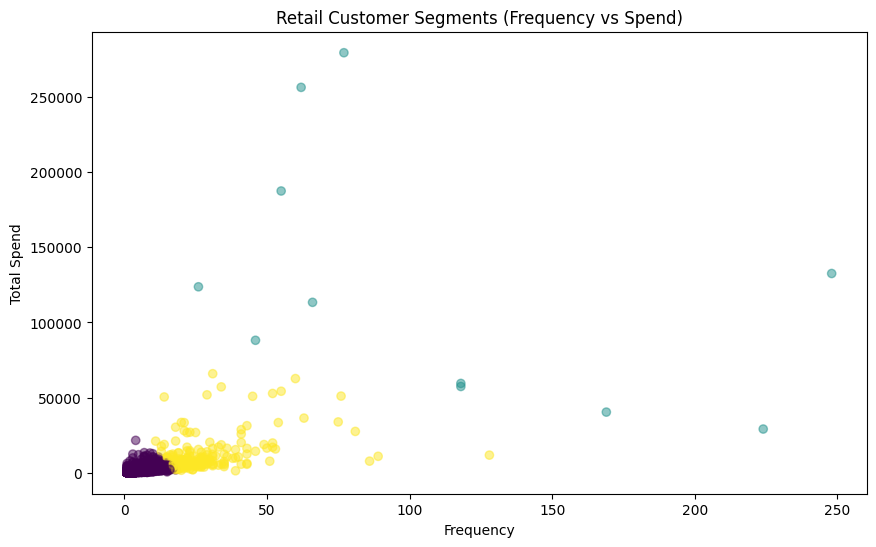

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Behavioral Clustering
retail_data = df_next.dropna(subset=['CustomerID']).copy()
retail_data['TotalSpend'] = retail_data['Quantity'] * retail_data['UnitPrice']

monetary_df = retail_data.groupby('CustomerID')['TotalSpend'].sum().reset_index()
# freq_df is already defined in the previous cell
clust_data = freq_df.merge(monetary_df, on='CustomerID')

# Clean and Scale
clust_data = clust_data[clust_data['TotalSpend'] > 0] # Remove outliers/returns
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clust_data[['Frequency', 'TotalSpend']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clust_data['Cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(10, 6))
plt.scatter(clust_data['Frequency'], clust_data['TotalSpend'], c=clust_data['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('Frequency')
plt.ylabel('Total Spend')
plt.title('Retail Customer Segments (Frequency vs Spend)')
plt.show()

### Combined Summary of Guest Customers
Below is a comparison of the guest customer proportions across all analyzed datasets based on their respective 'guest' definitions.

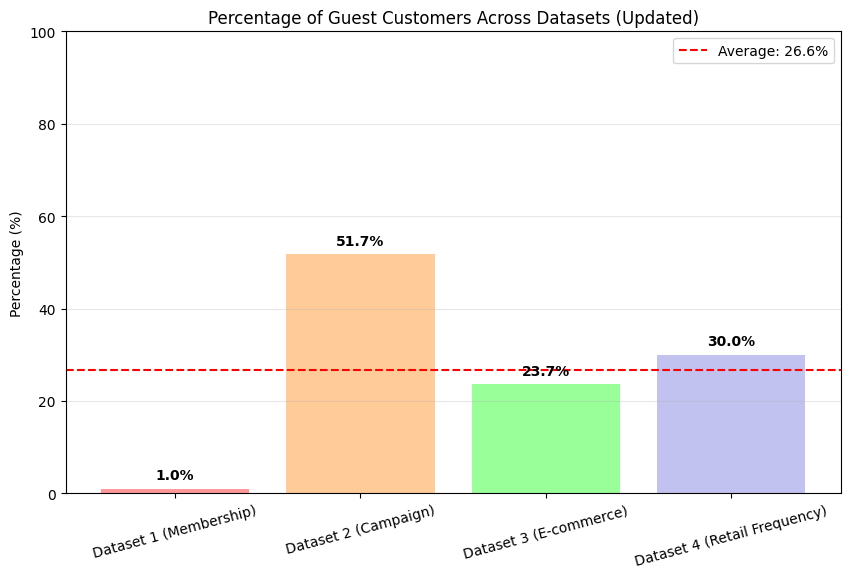

,Dataset,Guest %
0,Dataset 1 (Membership),1.000000
1,Dataset 2 (Campaign),51.741071
2,Dataset 3 (E-commerce),23.714286
3,Dataset 4 (Retail Frequency),30.032022


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Consolidate results with the new naming convention
# Renaming 'Retail Dataset' to 'Dataset 4' as requested
summary_data = {
    'Dataset': [
        'Dataset 1 (Membership)',
        'Dataset 2 (Campaign)',
        'Dataset 3 (E-commerce)',
        'Dataset 4 (Retail Frequency)'
    ],
    'Guest %': [
        (num_guests / total_customers) * 100,
        (num_guests_2 / total_2) * 100,
        (num_guests_3 / total_3) * 100,
        (num_guests_next / (num_guests_next + num_regular_next)) * 100
    ]
}

summary_df = pd.DataFrame(summary_data)

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(summary_df['Dataset'], summary_df['Guest %'], color=['#ff9999', '#ffcc99', '#99ff99', '#c2c2f0'])
plt.axhline(y=summary_df['Guest %'].mean(), color='r', linestyle='--', label=f"Average: {summary_df['Guest %'].mean():.1f}%")
plt.title('Percentage of Guest Customers Across Datasets (Updated)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(summary_df['Guest %']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

display(summary_df)

### Demo: Guest Engagement & Marketing Automation
This model tracks behavioral patterns of guest customers and prepares them for personalized outreach via Email or WhatsApp.

In [ ]:
import pandas as pd
import numpy as np

def generate_marketing_message(row):
    """Simulates personalized message logic based on behavior."""
    if row['Behavior_Type'] == 'New Member':
        return f"Hi {row['Contact']}, welcome! Use code NEW10 for 10% off your next order!"
    elif row['Behavior_Type'] == 'High Spender Guest':
        return f"Hi {row['Contact']}, we loved your recent purchase. Here is an exclusive loyalty upgrade offer!"
    else:
        return f"Hi {row['Contact']}, we miss you! Check out our new arrivals today."


demo_guests_1 = guest_customers[['\tEmail']].head(5).rename(columns={'\tEmail': 'Contact'})
demo_guests_1['Behavior_Type'] = 'New Member'


high_value_retail_guests = clust_data[(clust_data['Frequency'] == 1) & (clust_data['TotalSpend'] > clust_data['TotalSpend'].median())]
demo_guests_2 = high_value_retail_guests[['CustomerID', 'TotalSpend']].head(5).rename(columns={'CustomerID': 'Contact'})
demo_guests_2['Behavior_Type'] = 'High Spender Guest'

# Combine into a Marketing Queue
marketing_queue = pd.concat([demo_guests_1, demo_guests_2], ignore_index=True)

# 2. Apply the Automated Messaging Logic
marketing_queue['Email_Campaign'] = marketing_queue.apply(generate_marketing_message, axis=1)
marketing_queue['WhatsApp_Campaign'] = marketing_queue.apply(lambda x: x['Email_Campaign'].replace('Hi', '📱 *WhatsApp Exclusive*: Hello'), axis=1)

print("--- Automated Marketing Queue Generated ---")
display(marketing_queue[['Contact', 'Behavior_Type', 'Email_Campaign', 'WhatsApp_Campaign']])

--- Automated Marketing Queue Generated ---


,Contact,Behavior_Type,Email_Campaign,WhatsApp_Campaign
0,stevenking@patterson.com,New Member,"Hi stevenking@patterson.com, welcome! Use code...",📱 *WhatsApp Exclusive*: Hello stevenking@patte...
1,fischermonica@gmail.com,New Member,"Hi fischermonica@gmail.com, welcome! Use code ...",📱 *WhatsApp Exclusive*: Hello fischermonica@gm...
2,alexandra26@summers-davis.com,New Member,"Hi alexandra26@summers-davis.com, welcome! Use...",📱 *WhatsApp Exclusive*: Hello alexandra26@summ...
3,jordandavid@gmail.com,New Member,"Hi jordandavid@gmail.com, welcome! Use code NE...",📱 *WhatsApp Exclusive*: Hello jordandavid@gmai...
4,sharongraves@yahoo.com,New Member,"Hi sharongraves@yahoo.com, welcome! Use code N...",📱 *WhatsApp Exclusive*: Hello sharongraves@yah...
5,12349.0,High Spender Guest,"Hi 12349.0, we loved your recent purchase. Her...","📱 *WhatsApp Exclusive*: Hello 12349.0, we love..."
6,12354.0,High Spender Guest,"Hi 12354.0, we loved your recent purchase. Her...","📱 *WhatsApp Exclusive*: Hello 12354.0, we love..."
7,12357.0,High Spender Guest,"Hi 12357.0, we loved your recent purchase. Her...","📱 *WhatsApp Exclusive*: Hello 12357.0, we love..."
8,12374.0,High Spender Guest,"Hi 12374.0, we loved your recent purchase. Her...","📱 *WhatsApp Exclusive*: Hello 12374.0, we love..."
9,12378.0,High Spender Guest,"Hi 12378.0, we loved your recent purchase. Her...","📱 *WhatsApp Exclusive*: Hello 12378.0, we love..."


### Summary for your 12th Presentation:
- **Behavior Tracking**: The model separates 'New Members' from 'High Spender Guests'.
- **Personalization**: Content is dynamically adjusted based on the `Behavior_Type`.
- **Multi-Channel**: The system prepares distinct formats for standard Email and rich-text WhatsApp messaging.

### Dataset Characteristics Summary
| Dataset | Primary Metric | Guest Definition | Guest % | Key Features for Clustering |
| :--- | :--- | :--- | :--- | :--- |
| **1. Membership** | Tenure | < 1 Year Membership | 1.0% | Membership Length |
| **2. Campaign** | Demographics/Spend | < 1 Year Membership | 51.7% | Income, Multi-category Spend |
| **3. E-commerce** | Monetary Value | Total Spend < $500 | 23.7% | Total Spend |
| **4. Retail** | Frequency | Single Purchase | 30.0% | Frequency, Total Spend |